In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy
import math

In [5]:
columns = ["Size(sqft)","Number of Bedrooms","Number of floors","Age of Home","Price (1000s dollars)"]
df = pd.read_csv(r"E:\SALEH\Data\houses.txt",names=columns)

In [6]:
df.head()

,Size(sqft),Number of Bedrooms,Number of floors,Age of Home,Price (1000s dollars)
0,952.0,2.0,1.0,65.0,271.5
1,1244.0,3.0,1.0,64.0,300.0
2,1947.0,3.0,2.0,17.0,509.8
3,1725.0,3.0,2.0,42.0,394.0
4,1959.0,3.0,2.0,15.0,540.0


---
# exploring the Data
Plotting each feature vs. the target, price, provides some indication of which features have the strongest influence on price. Above, increasing size also increases price. 

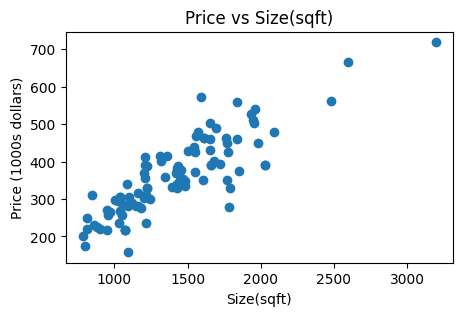

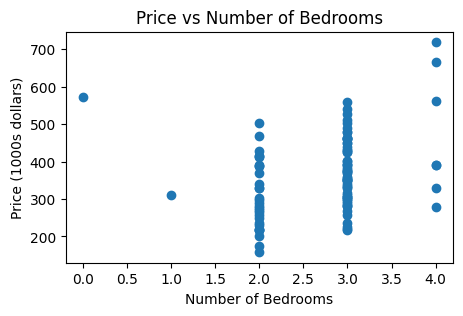

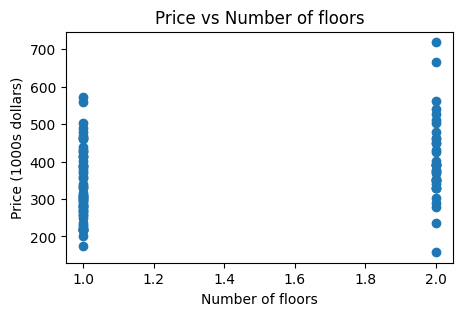

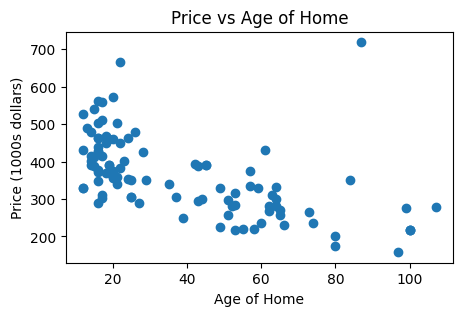

In [7]:
import matplotlib.pyplot as plt

for label in df.columns[:-1]:
    plt.figure(figsize=(5, 3))
    plt.scatter(df[label], df["Price (1000s dollars)"],)
    plt.title(f"Price vs {label}")
    plt.xlabel(label)
    plt.ylabel("Price (1000s dollars)")
    plt.show()
    


#### `Bedrooms` and `floors` don't seem to have a strong impact on price. `Newer houses` have higher prices than `older houses`.

In [8]:
#X_train = df.drop(['Price (1000s dollars)'], axis=1)
#y_train = df['Price (1000s dollars)']

In [9]:
X_train = df.drop(['Number of floors', 'Number of Bedrooms', 'Price (1000s dollars)'], axis=1) # working on only 2 features
y_train = df['Price (1000s dollars)'] # target 

In [10]:
X_train = np.array(X_train)
y_train = np.array(y_train)

In [412]:
X_train.shape,y_train.shape

((100, 2), (100,))

---



In [11]:
def compute_cost(x,y,w,b):
    m = x.shape[0] # num of training ex
    cost = 0

    for i in range(m):
        f_wb_i = np.dot(x[i],w) + b # scalar

        cost = cost + (f_wb_i - y[i])**2 #scalar

    cost = cost/(2*m)
    return cost

###################################################################################### 
def compute_gradient(x,y,w,b):

    m, n = x.shape # m examples , n features

    dj_dw = np.zeros((n,)) # create 1d array [0,0,0,0]
    dj_db = 0

    for i in range(m): # (m) examples 
        error = (np.dot(x[i],w)+ b) - y[i] # computes the error y^i - yi

        for j in range(n): # (n) features

            dj_dw[j]+=   error * x[i,j] # partial derivative dj_dw

        dj_db += error # partial derivative dj_db

    dj_dw = dj_dw / m                                
    dj_db = dj_db / m
    
    return dj_dw ,dj_db
        
################################################################################################################
def gradient_descent(x,y,w_in,b_in,compute_cost,compute_gradient,alpha,num_iters):

    j_history = []
    w = copy.deepcopy(w_in)
    b = b_in

    for i in range(num_iters):
        dj_dw,dj_db = compute_gradient(x,y,w,b)
        # parameter updates 
        w = w - alpha * dj_dw 
        b = b - alpha * dj_db

        if i < 100000 : # cost history
            j_history.append(compute_cost(x,y,w,b))
    

        if i % math.ceil(num_iters/10)==0:
            print(f"Iteration {i:4d}: Cost {j_history[-1]:8.2f}")

    return w,b, j_history
            

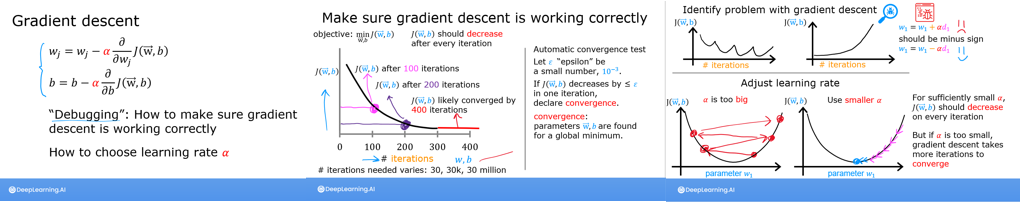





### $\alpha$ = 9.9e-7

In [12]:
w_init = np.array([ 0.39133535, 18.75376741])
initial_w = np.zeros_like(w_init)
initial_b = 0.0


iterations = 1000
alpha = 0.00000099 #

w_final , b_final,J_hist = gradient_descent(X_train,y_train,initial_w,initial_b,compute_cost,compute_gradient,alpha,iterations)


Iteration    0: Cost 93104.03
Iteration  100: Cost 89159807343582320.00
Iteration  200: Cost 86846196013221925023482118144.00
Iteration  300: Cost 84592620673826087787312525949669449138176.00
Iteration  400: Cost 82397523449114904959119345748313851167756459897257984.00
Iteration  500: Cost 80259386888201499774740352008421704012805645591533752965492899840.00
Iteration  600: Cost 78176732916591275589320884654877019983463689730571894840754321357099344330752.00
Iteration  700: Cost 76148121814401071461362544294909007377472773311624298426312149597846648164428652935643136.00
Iteration  800: Cost 74172151221099977927405722305862635070748340834465195525963068016106518101592818954742413974361341952.00
Iteration  900: Cost 72247455166060569677898252030234285343898658944257243395075489559054211211013443252552193157799120867386508443648.00


In [13]:
print(f"b,w found by gradient descent: {b_final:0.2f},{w_final} ")
m,_ = X_train.shape
m
print(f"prediction: {np.dot(X_train[99], w_final) + b_final:0.2f}, target value: {y_train[99]}")

b,w found by gradient descent: -144608844624762667318022995543015713643806414650977812480.00,[-2.21794348e+59 -5.29711988e+57] 
prediction: -233228522754491772841205060274214922230747724936150494857920512.00, target value: 257.8


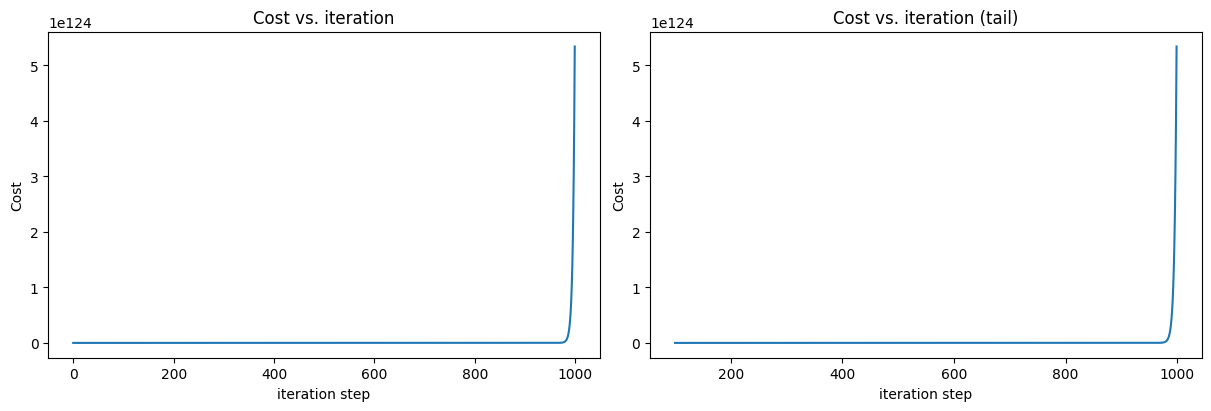

In [14]:
# plot cost versus iteration  
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12, 4))
ax1.plot(J_hist)
ax2.plot(100 + np.arange(len(J_hist[100:])), J_hist[100:])
ax1.set_title("Cost vs. iteration");  ax2.set_title("Cost vs. iteration (tail)")
ax1.set_ylabel('Cost')             ;  ax2.set_ylabel('Cost') 
ax1.set_xlabel('iteration step')   ;  ax2.set_xlabel('iteration step') 
plt.show()

## It appears the learning rate is too `high`.  The solution does not converge. Cost is *increasing* rather than decreasing.

------
### $\alpha$ = 9e-7
Let's try a bit smaller value and see what happens.

In [417]:
w_init = np.array([ 0.39133535, 18.75376741])
initial_w = np.zeros_like(w_init)
initial_b = 0.0


iterations = 900
alpha =0.0000009 # NEW Alpha

w_final , b_final,J_hist = gradient_descent(X_train,y_train,initial_w,initial_b,compute_cost,compute_gradient,alpha,iterations)


Iteration    0: Cost 64612.62
Iteration   90: Cost  1547.32
Iteration  180: Cost  1509.41
Iteration  270: Cost  1485.65
Iteration  360: Cost  1465.20
Iteration  450: Cost  1447.58
Iteration  540: Cost  1432.41
Iteration  630: Cost  1419.35
Iteration  720: Cost  1408.10
Iteration  810: Cost  1398.41


In [418]:
print(f"b,w found by gradient descent: {b_final:0.2f},{w_final} ")
m,_ = X_train.shape
for i in range(m):
    print(f"prediction: {np.dot(X_train[i], w_final) + b_final:0.2f}, target value: {y_train[i]}")

b,w found by gradient descent: 0.00,[ 0.26184767 -0.36645013] 
prediction: 225.46, target value: 271.5
prediction: 302.29, target value: 300.0
prediction: 503.59, target value: 509.8
prediction: 436.30, target value: 394.0
prediction: 507.47, target value: 540.0
prediction: 338.94, target value: 415.0
prediction: 202.06, target value: 230.0
prediction: 474.53, target value: 560.0
prediction: 252.90, target value: 294.0
prediction: 804.46, target value: 718.2
prediction: 177.02, target value: 200.0
prediction: 307.99, target value: 302.0
prediction: 401.11, target value: 468.0
prediction: 367.12, target value: 374.2
prediction: 313.96, target value: 388.0
prediction: 262.49, target value: 282.0
prediction: 215.82, target value: 311.8
prediction: 432.00, target value: 401.0
prediction: 456.36, target value: 449.8
prediction: 256.20, target value: 301.0
prediction: 424.88, target value: 502.0
prediction: 272.07, target value: 340.0
prediction: 339.47, target value: 400.282
prediction: 409

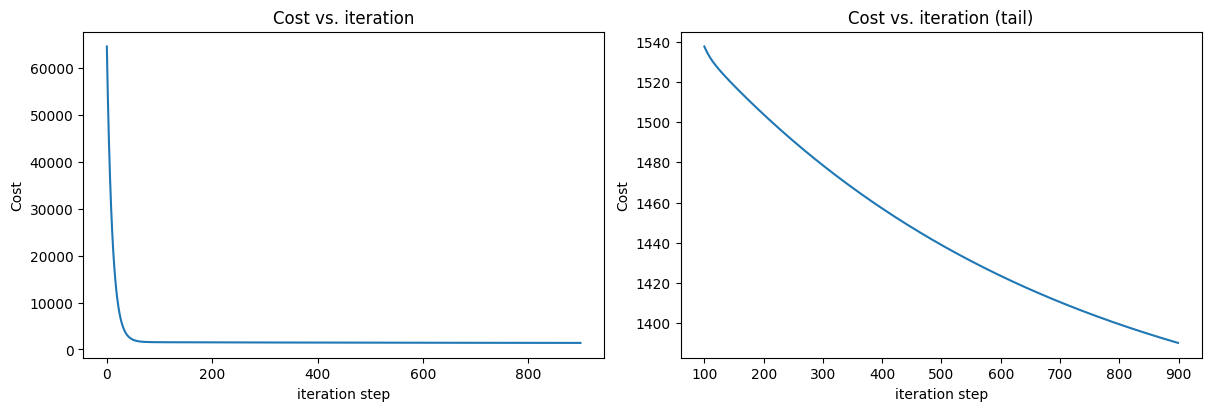

In [419]:
# plot cost versus iteration  
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12, 4))
ax1.plot(J_hist)
ax2.plot(100 + np.arange(len(J_hist[100:])), J_hist[100:])
ax1.set_title("Cost vs. iteration");  ax2.set_title("Cost vs. iteration (tail)")
ax1.set_ylabel('Cost')             ;  ax2.set_ylabel('Cost') 
ax1.set_xlabel('iteration step')   ;  ax2.set_xlabel('iteration step') 
plt.show()

Cost is decreasing throughout the run showing that $\alpha$ is not too large. 
----

# Feature scaling

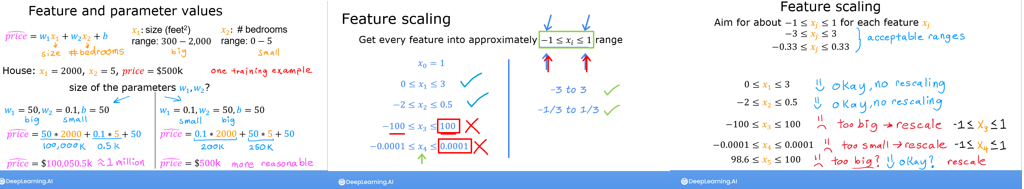

The importance of rescaling the dataset so the features have a similar range.

## 1-  Maximum Normalization 

Maximum normalization scales each feature by dividing it by its `maximum value`, so that all feature values lie in the range [0, 1].

$ Xscaled= \dfrac {x}{max(x)} $

In [420]:
x = df['Age of Home'] # feature 1 
y = df['Size(sqft)'] # feature 2

x_scaled = x/(np.max(x))
y_scaled = y/(np.max(y))

# visiualization

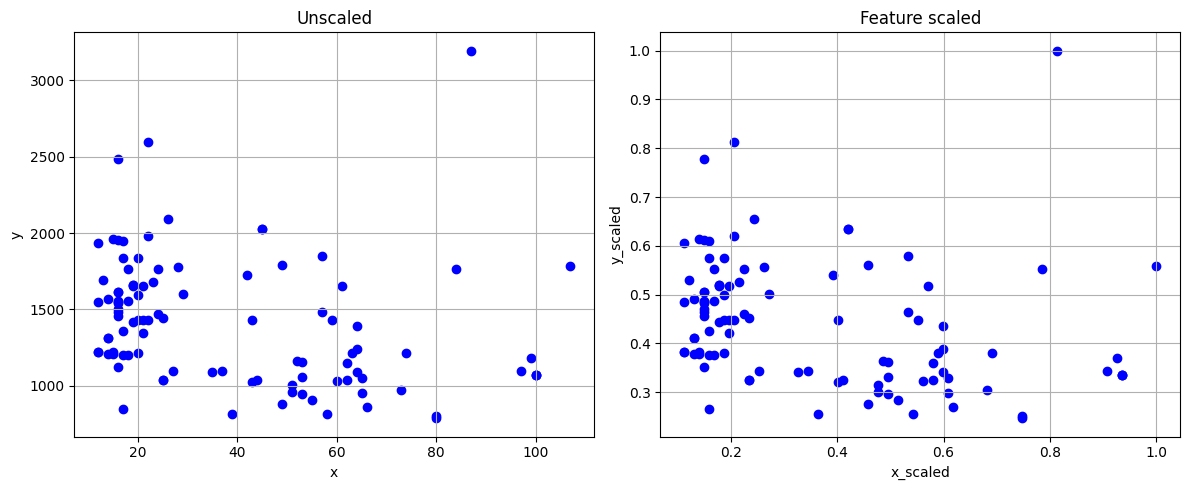

In [421]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns

# Unscaled plot
axes[0].scatter(x, y, c='blue')
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_title("Unscaled")
axes[0].grid(True)

# Scaled plot
axes[1].scatter(x_scaled, y_scaled, c='blue')
axes[1].set_xlabel("x_scaled")
axes[1].set_ylabel("y_scaled")
axes[1].set_title("Feature scaled")
axes[1].grid(True)

plt.tight_layout()
plt.show()


---

## 2- z-score normalization

After z-score normalization, all features will have a mean of 0 and a standard deviation of 1.

formula:
$$x^{(i)}_j = \dfrac{x^{(i)}_j - \mu_j}{\sigma_j} \ $$ 

where $j$ selects a feature or a column in the $\mathbf{X}$ matrix. $µ_j$ is the mean of all the values for feature (j) and $\sigma_j$ is the standard deviation of feature (j).

\begin{align}
\mu_j &= \frac{1}{m} \sum_{i=0}^{m-1} x^{(i)}_j \\\
\sigma^2_j &= \frac{1}{m} \sum_{i=0}^{m-1} (x^{(i)}_j - \mu_j)^2  \
\end{align}


In [422]:
x_zscore = (x - np.mean(x,axis= 0 )) /np.std(x,axis= 0 )
y_zscore = (y-np.mean(y,axis= 0)) / np.std(y,axis= 0)

In [423]:
print(np.mean(x_zscore), np.std(x_zscore))

3.552713678800501e-17 1.0


In [424]:
print(np.mean(y_zscore), np.std(y_zscore))

-8.326672684688674e-17 0.9999999999999999


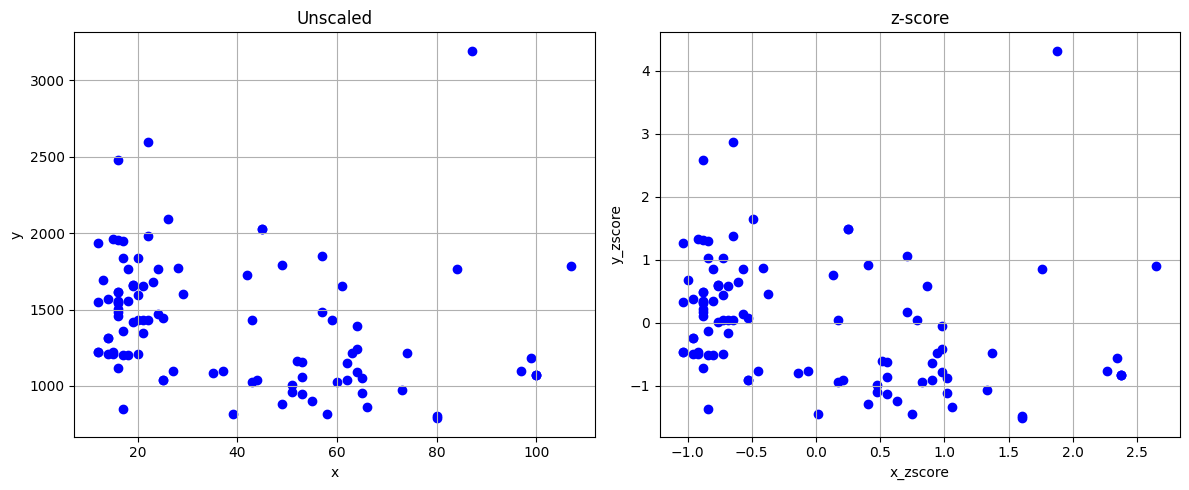

In [425]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns

# Unscaled plot
axes[0].scatter(x, y, c='blue')
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_title("Unscaled")
axes[0].grid(True)

# Scaled plot
axes[1].scatter(x_zscore, y_zscore, c='blue')
axes[1].set_xlabel("x_zscore")
axes[1].set_ylabel("y_zscore")
axes[1].set_title("z-score")
axes[1].grid(True)

plt.tight_layout()
plt.show()


The plot above shows the relationship between two of the training set parameters, "age" and "size(sqft)". *These are plotted with equal scale*. 
- Left: Unnormalized: The range of values or the variance of the 'size(sqft)' feature is much larger than that of age
- Right: The second step divides by the standard deviation. This leaves both features centered at zero with a similar scale.
---

# 3-Mean normailzation
- The mean becomes 0
- The values are typically in the range [−1,1]

formula:
$$xscaled = \dfrac{x - \mu}{max(x)-min(x)} \ $$ 

where 

- $ \mu$ = `mean` of the feature
- $ max(x), min(𝑥) = $ max and min values of the feature


In [426]:
x_mean_norm = (x - np.mean(x, axis=0)) / (np.max(x,axis=0) - np.min(x,axis=0))
y_mean_norm = (y - np.mean(y, axis=0)) / (np.max(y,axis=0) - np.min(y,axis=0))


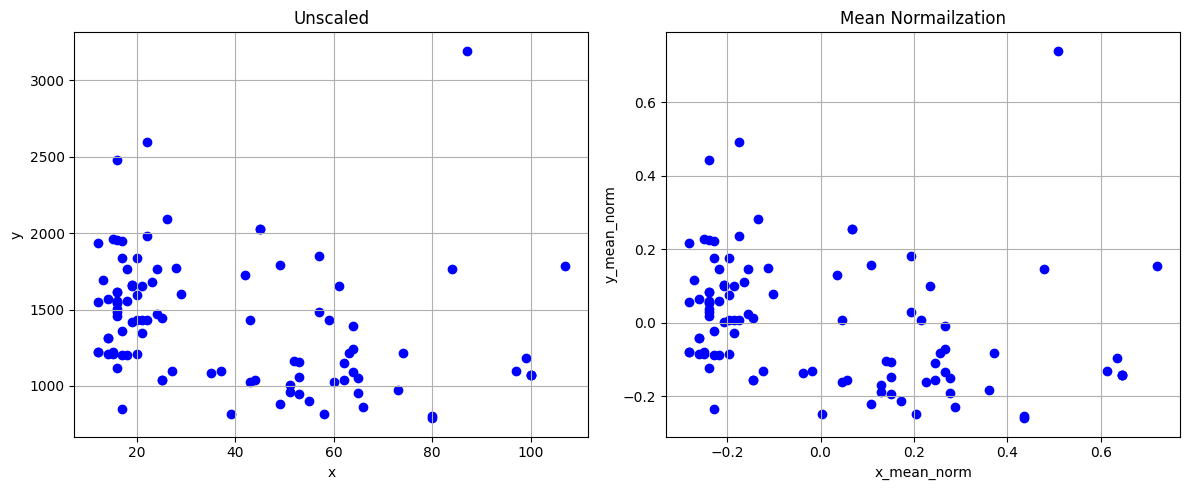

In [427]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns

# Unscaled plot
axes[0].scatter(x, y, c='blue')
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_title("Unscaled")
axes[0].grid(True)

# Scaled plot
axes[1].scatter(x_mean_norm, y_mean_norm, c='blue')
axes[1].set_xlabel("x_mean_norm")
axes[1].set_ylabel("y_mean_norm")
axes[1].set_title("Mean Normailzation")
axes[1].grid(True)

plt.tight_layout()
plt.show()


# Gradient Descent with normalized data

Using `zscore` normalization

In [428]:
X_train_zscore = (X_train - np.mean(X_train,axis= 0 )) / np.std(X_train,axis= 0)

In [429]:
w_norm , b_norm,J_hist = gradient_descent(X_train_zscore,y_train,initial_w,initial_b,compute_cost,compute_gradient,0.2,30)
print(f"w_norm,b_norm found w =  {w_norm} b = {b_norm}")

Iteration    0: Cost 45385.30
Iteration    3: Cost 12257.56
Iteration    6: Cost  3737.94
Iteration    9: Cost  1529.38
Iteration   12: Cost   953.31
Iteration   15: Cost   802.27
Iteration   18: Cost   762.46
Iteration   21: Cost   751.90
Iteration   24: Cost   749.09
Iteration   27: Cost   748.33
w_norm,b_norm found w =  [ 78.52494585 -38.82641412] b = 361.7910891943805


In [430]:
print(f"b,w found by gradient descent: {b_final:0.2f},{w_final} ")
m,_ = X_train.shape
for i in range(m):
    print(f"prediction: {np.dot(X_train_zscore[i], w_norm) + b_norm:0.2f}, target value: {y_train[i]}")

b,w found by gradient descent: 0.00,[ 0.26184767 -0.36645013] 
prediction: 234.15, target value: 271.5
prediction: 291.29, target value: 300.0
prediction: 495.99, target value: 509.8
prediction: 416.05, target value: 394.0
prediction: 501.29, target value: 540.0
prediction: 379.91, target value: 415.0
prediction: 215.88, target value: 230.0
prediction: 474.84, target value: 560.0
prediction: 281.38, target value: 294.0
prediction: 628.16, target value: 718.2
prediction: 180.32, target value: 200.0
prediction: 353.68, target value: 302.0
prediction: 420.18, target value: 468.0
prediction: 392.98, target value: 374.2
prediction: 360.50, target value: 388.0
prediction: 262.33, target value: 282.0
prediction: 286.62, target value: 311.8
prediction: 436.47, target value: 401.0
prediction: 460.38, target value: 449.8
prediction: 282.54, target value: 301.0
prediction: 433.77, target value: 502.0
prediction: 305.23, target value: 340.0
prediction: 380.29, target value: 400.282
prediction: 424

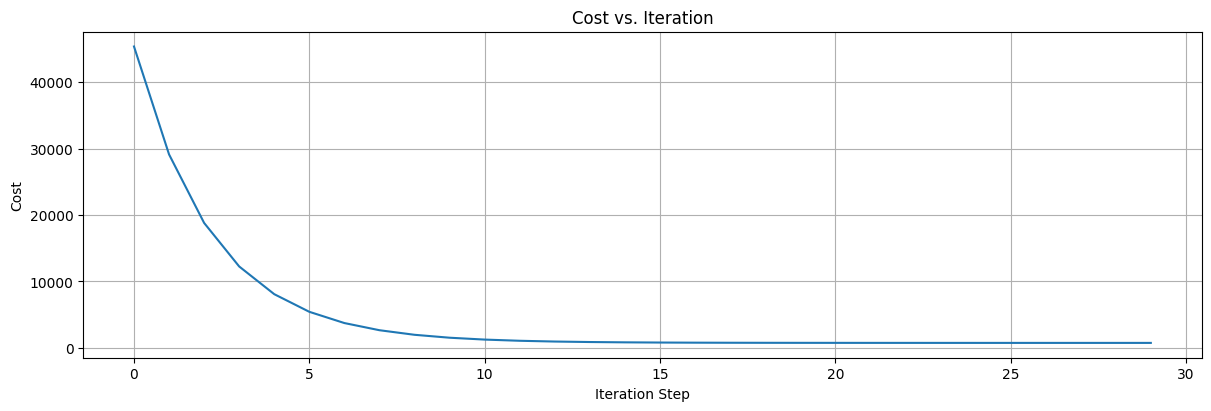

In [431]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4), constrained_layout=True)
plt.plot(J_hist)
plt.title("Cost vs. Iteration")
plt.xlabel("Iteration Step")
plt.ylabel("Cost")
plt.grid(True)
plt.show()


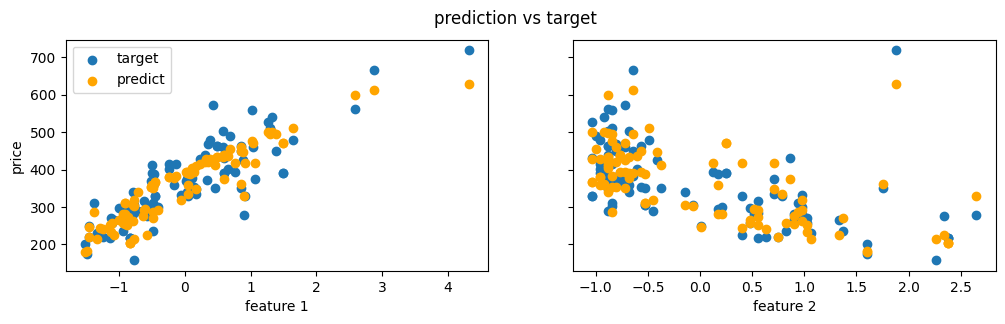

In [458]:
m = X_train_zscore.shape[0]
yp = np.zeros(m)

for i in range(m):
    yp[i] = np.dot(X_train_zscore[i],w_norm) + b_norm

fig,ax = plt.subplots(1,2,figsize = (12,3),sharey=True)

for i in range(X_train_zscore.shape[1]):
    ax[i].scatter(X_train_zscore[:,i],y_train,label = "target")
    ax[i].scatter(X_train_zscore[:,i], yp,color = 'orange',label = "predict")
    ax[i].set_xlabel(f"feature {i+1}")

ax[0].set_ylabel("price")
ax[0].legend()
plt.suptitle("prediction vs target")
plt.show()
    
